In [12]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import pickle
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, make_tall_subplots
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}


%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [13]:
make_tall_subplots?

Signature:
make_tall_subplots(
    nrow=3,
    ncol=1,
    panel_width=2.0,
    panel_height=1.2,
    row_spacing=None,
    col_spacing=None,
    return_fig=False,
)
Docstring:
Multi-row, multi-column figure with physically fixed panel sizes.
All panels share the same rect shape defined by panel_width × panel_height.
Font sizes set in points will render at true physical size when included
directly in LaTeX (no scaling).

Parameters
----------
nrow         : int   — number of panel rows
ncol         : int   — number of panel columns
panel_width  : float — panel width in inches
panel_height : float — panel height in inches
row_spacing  : list  — nrow+1 floats [bottom_margin, gap1, ..., top_margin]
                       defaults to [MARGIN_LABEL, MARGIN_SHARED*(nrow-1), MARGIN_TICKS]
col_spacing  : list  — ncol+1 floats [left_margin, gap1, ..., right_margin]
                       defaults to [MARGIN_LABEL, MARGIN_SHARED*(ncol-1), MARGIN_TICKS]

Returns
-------
axes : 2D numpy array of s

In [3]:
folder_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar_viz_haew/"

In [57]:
mstar_bin = "7.75_8.25"


wave = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_gt100.fits")[3].data
flux_100 = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_gt100.fits")[1].data

wave = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_gt100.fits")[3].data
flux_30 = fits.open(f"{folder_path}/stack_ALL_mstar_{mstar_bin}_ew_lt30.fits")[1].data

cont_norm_mask = (wave > 5200) & (wave < 5800)

flux_100_cont_val = np.median( flux_100[0][cont_norm_mask] )
flux_30_cont_val = np.median( flux_30[0][cont_norm_mask] )

scale_factor = flux_100_cont_val/flux_30_cont_val

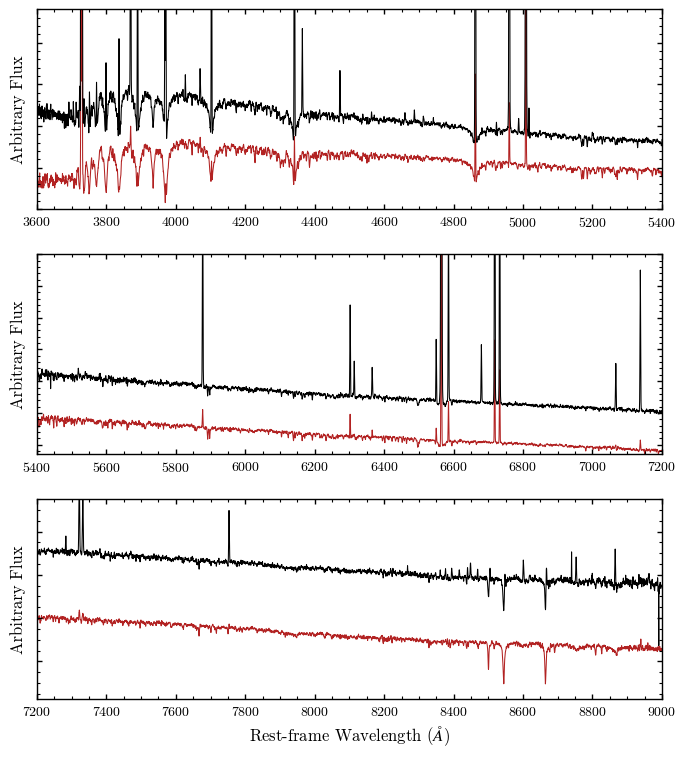

In [75]:
fig,ax = make_tall_subplots(
    nrow=3,
    ncol=1,
    panel_width=6.25,
    panel_height=2,
    row_spacing=[MARGIN_LABEL-0.4, MARGIN_TICKS, MARGIN_TICKS, MARGIN_PAD],
    col_spacing=[MARGIN_LABEL-0.45, MARGIN_PAD],
    return_fig=True,
)

lw_val = 0.75

for i in range(3):
    #we want to make them such that they have same continuum level and then shift things linearly around
    ax[i][0].plot(wave,flux_100[0], lw = lw_val, color= "k", zorder=1)

    ax[i][0].plot(wave,flux_30[0]*scale_factor - 0.0035, lw = lw_val, color= "firebrick", zorder=0)
    
    ax[0][0].set_ylim(0,0.024)
    ax[1][0].set_ylim(0.00175,0.0175)
    ax[2][0].set_ylim(-0.00175,0.0075)
    ax[i][0].set_yticklabels([])
    
ax[0][0].set_xlim([3600,3600+ 1800])
ax[1][0].set_xlim([3600+ 1800,3600+ 1800 + 1800])
ax[2][0].set_xlim([3600+ 1800 + 1800,3600+ 1800 + 1800 + 1800])

ax[0][0].set_ylabel(r"Arbitrary Flux")
ax[1][0].set_ylabel(r"Arbitrary Flux")
ax[2][0].set_ylabel(r"Arbitrary Flux")


ax[2][0].set_xlabel(r"Rest-frame Wavelength ($\AA$)")

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stacked_spectra_viz.pdf")

plt.show()

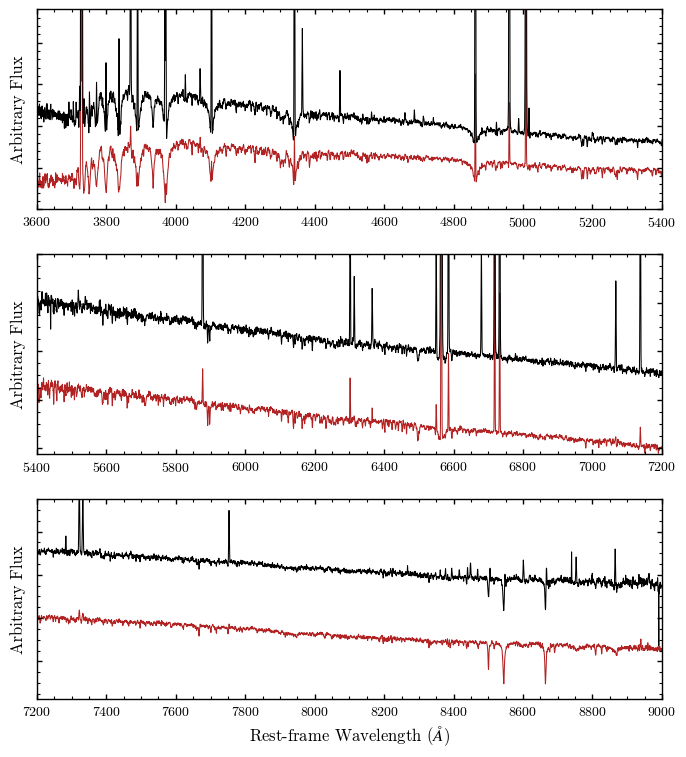

In [78]:
fig,ax = make_tall_subplots(
    nrow=3,
    ncol=1,
    panel_width=6.25,
    panel_height=2,
    row_spacing=[MARGIN_LABEL-0.4, MARGIN_TICKS, MARGIN_TICKS, MARGIN_PAD],
    col_spacing=[MARGIN_LABEL-0.45, MARGIN_PAD],
    return_fig=True,
)

lw_val = 0.75

for i in range(3):
    #we want to make them such that they have same continuum level and then shift things linearly around
    ax[i][0].plot(wave,flux_100[0], lw = lw_val, color= "k", zorder=1)

    ax[i][0].plot(wave,flux_30[0]*scale_factor - 0.0035, lw = lw_val, color= "firebrick", zorder=0)
    
    ax[0][0].set_ylim(0,0.024)
    ax[1][0].set_ylim(0.00175,0.01)
    ax[2][0].set_ylim(-0.00175,0.0075)
    ax[i][0].set_yticklabels([])
    
ax[0][0].set_xlim([3600,3600+ 1800])
ax[1][0].set_xlim([3600+ 1800,3600+ 1800 + 1800])
ax[2][0].set_xlim([3600+ 1800 + 1800,3600+ 1800 + 1800 + 1800])

ax[0][0].set_ylabel(r"Arbitrary Flux")
ax[1][0].set_ylabel(r"Arbitrary Flux")
ax[2][0].set_ylabel(r"Arbitrary Flux")


ax[2][0].set_xlabel(r"Rest-frame Wavelength ($\AA$)")
plt.show()